In [1]:
import os
import zipfile
import requests
import shutil
from pathlib import Path
import kagglehub
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


# telechargement du dataset de kaggle
path = kagglehub.dataset_download("anaghachoudhari/pcos-detection-using-ultrasound-images")
path = Path(path)

print("Path to dataset files:", path)



Path to dataset files: /kaggle/input/pcos-detection-using-ultrasound-images


In [2]:
subfolder_path = path / "data" / "train"
categories = ['infected', 'notinfected']
total_train_images = 0
category_counts_train = {category: len(list((subfolder_path / category).glob("*.*"))) for category in categories}

#Calculer le nombre total
total_train_images = sum(category_counts_train.values())
for category, count in category_counts_train.items():
    print(f"{category}: {count} images")

print(f"\nTotal d'images entrainer: {total_train_images}")

infected: 781 images
notinfected: 1143 images

Total d'images entrainer: 1924


In [3]:
#montrer juste le pourcentage
print(f"\nTotal d'images entrainer: {total_train_images}")
for count in category_counts_train.values():
    print(f"{(count / total_train_images) * 100:.2f}%")




Total d'images entrainer: 1924
40.59%
59.41%


In [4]:
subfolder_path = path / "data" / "test"
categories = ['infected', 'notinfected']
total_test_images = 0
category_counts_test = {category: len(list((subfolder_path / category).glob("*.*"))) for category in categories}

#Calculer le nombre total
total_test_images = sum(category_counts_test.values())
for category, count in category_counts_test.items():
    print(f"{category}: {count} images")

print(f"\nTotal d'images a tester: {total_test_images}")


infected: 787 images
notinfected: 1145 images

Total d'images a tester: 1932


In [5]:
#montrer juste le pourcentage
print(f"\nTotal d'images entrainer: {total_test_images}")
for count in category_counts_test.values():
    print(f"{(count / total_train_images) * 100:.2f}%")




Total d'images entrainer: 1932
40.90%
59.51%


In [6]:
#Calculer le total au complet
total_images = total_test_images + total_train_images
print(f"\nTotal images in entire dataset: {total_images}")
for category in categories:
    count = category_counts_test.get(category, 0) + category_counts_train.get(category, 0)
    print(f"{category}: {count} images ({(count / total_images) * 100:.2f}%)")



Total images in entire dataset: 3856
infected: 1568 images (40.66%)
notinfected: 2288 images (59.34%)


In [7]:
print(f"Total Test Images: {total_test_images}")
print(f"Total Train Images: {total_train_images}")


Total Test Images: 1932
Total Train Images: 1924


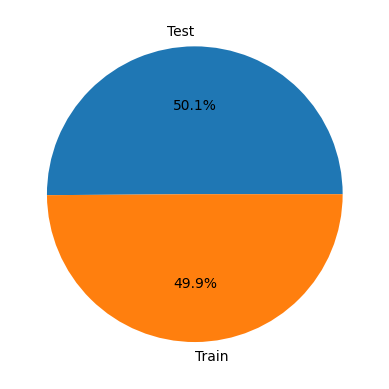

In [8]:
labels = ['Test', 'Train']
sizes = [total_test_images, total_train_images]

plt.pie(sizes,labels=labels, autopct='%1.1f%%')
plt.show()

In [12]:
!pip install SimpleITK


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 14.3 MB/s eta 0:00:00


Path au donnee: /kaggle/input/pcos-detection-using-ultrasound-images


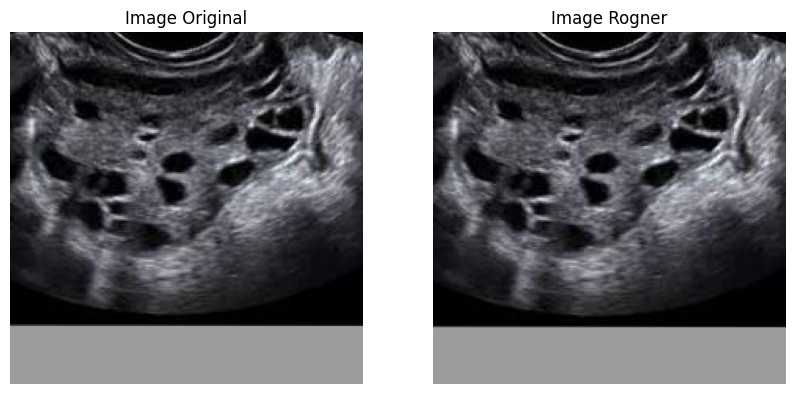

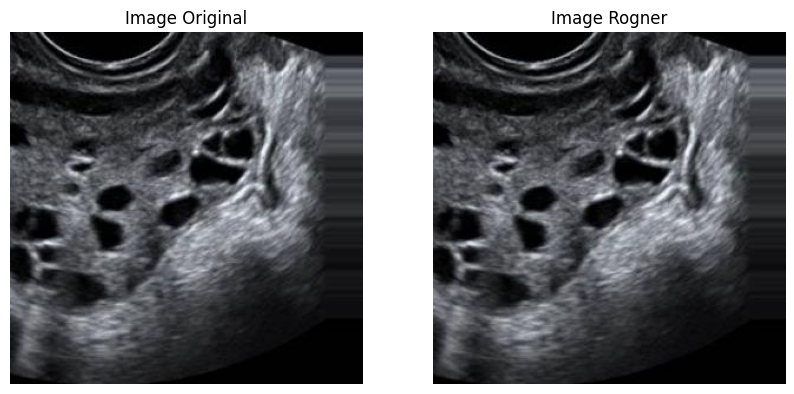

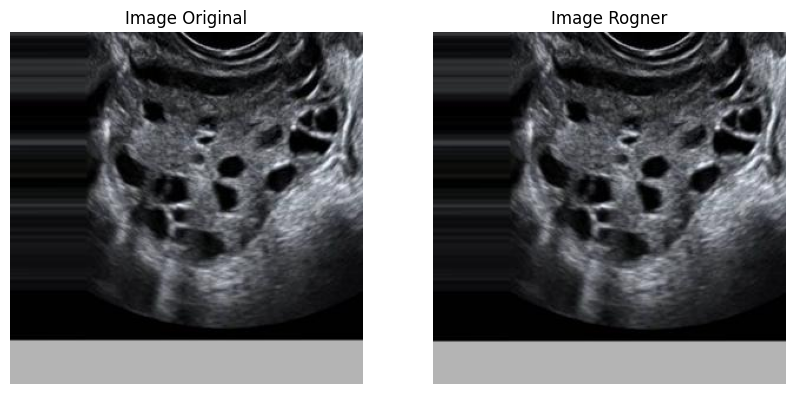

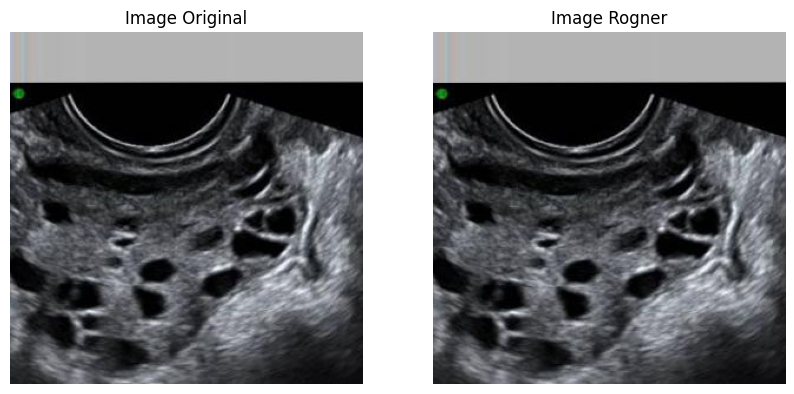

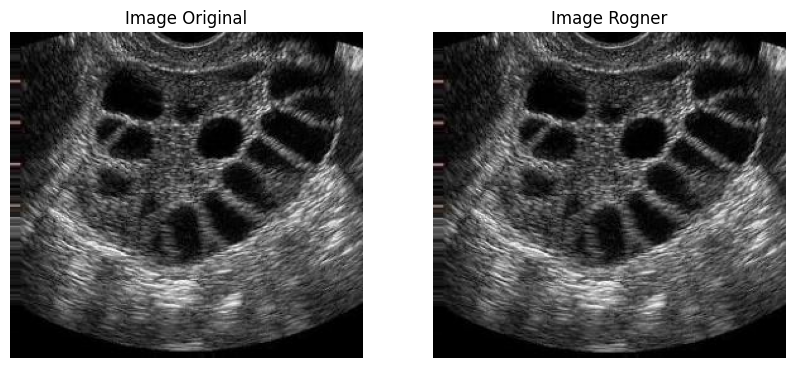

infected: 781 images in train dataset
notinfected: 1143 images in train dataset

Total images in train dataset: 1924
Failed to process /kaggle/input/pcos-detection-using-ultrasound-images/data/test/infected/WhatsApp Image 2022-04-01 at 3.49.22 PM.jpeg: cannot identify image file '/kaggle/input/pcos-detection-using-ultrasound-images/data/test/infected/WhatsApp Image 2022-04-01 at 3.49.22 PM.jpeg'
Failed to process /kaggle/input/pcos-detection-using-ultrasound-images/data/test/infected/WhatsApp Image 2022-04-01 at 3.49.45 PM.jpeg: cannot identify image file '/kaggle/input/pcos-detection-using-ultrasound-images/data/test/infected/WhatsApp Image 2022-04-01 at 3.49.45 PM.jpeg'
Failed to process /kaggle/input/pcos-detection-using-ultrasound-images/data/test/infected/WhatsApp Image 2022-04-01 at 3.50.20 PM.jpeg: cannot identify image file '/kaggle/input/pcos-detection-using-ultrasound-images/data/test/infected/WhatsApp Image 2022-04-01 at 3.50.20 PM.jpeg'
Failed to process /kaggle/input/pcos-

In [18]:
import os
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import kagglehub

def crop_to_content(image):

    grayscale = np.array(image.convert("L"))

    # detection des regions non-zeros, grace au grayscale
    non_zero_coords = np.argwhere(grayscale > 0)
    if non_zero_coords.size == 0:
        return image

    #Obtenir la boite limitante
    top_left = non_zero_coords.min(axis=0)
    bottom_right = non_zero_coords.max(axis=0)

    # rogner l'image
    cropped_image = image.crop((*top_left[::-1], *bottom_right[::-1]))
    return cropped_image

path = kagglehub.dataset_download("anaghachoudhari/pcos-detection-using-ultrasound-images")
path = Path(path)

print("Path au donnee:", path)
dataset_splits = ["train", "test"]
categories = ['infected', 'notinfected']

# Nouvelle base pour les images rogner
cropped_base_dir = Path("/content/cropped_data")
cropped_base_dir.mkdir(parents=True, exist_ok=True)

train_images_displayed = 0

for split in dataset_splits:
    subfolder_path = path / "data" / split
    cropped_dir = cropped_base_dir / split
    cropped_dir.mkdir(parents=True, exist_ok=True)

    category_counts = {}
    for category in categories:
        category_path = subfolder_path / category
        cropped_category_path = cropped_dir / category
        cropped_category_path.mkdir(parents=True, exist_ok=True)

        images = list(category_path.glob("*.*"))
        category_counts[category] = len(images)

        for img_path in images:
            try:
                img = Image.open(img_path)

                # Appliquer le changement (rogner)
                cropped_img = crop_to_content(img)

                #sauvegarder
                cropped_img.save(cropped_category_path / img_path.name)

                #Montrer les 5 images
                if split == "train" and train_images_displayed < 5:
                    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
                    axes[0].imshow(img)
                    axes[0].set_title("Image Original")
                    axes[0].axis("off")

                    axes[1].imshow(cropped_img)
                    axes[1].set_title("Image Rogner")
                    axes[1].axis("off")

                    plt.show()

                    train_images_displayed += 1

            except Exception as e:
                print(f"Failed to process {img_path}: {e}")

    #Calculer le nombre total
    total_images = sum(category_counts.values())
    for category, count in category_counts.items():
        print(f"{category}: {count} images in {split} dataset")

    print(f"\nTotal images in {split} dataset: {total_images}")


In [21]:
from torchvision.datasets import DatasetFolder
from torchvision import transforms
from torch.utils.data import DataLoader
from PIL import Image, UnidentifiedImageError
from pathlib import Path

# Configuration
IMG_SIZE = 224
BATCH_SIZE = 16

class SafeImageFolder(DatasetFolder):
    def __init__(self, root, transform=None):
        super().__init__(root, loader=self.safe_loader, extensions=('jpg', 'jpeg', 'png', 'JPG', 'JPEG', 'PNG'))
        self.transform = transform

    @staticmethod
    def safe_loader(path):
        try:
            with Image.open(path) as img:
                return img.convert("RGB")
        except (IOError, SyntaxError, UnidentifiedImageError) as e:
            print(f"Skipping corrupted image: {path} ({e})")
            return None

    def __getitem__(self, index):
        path, target = self.samples[index]
        sample = self.loader(path)

        # Si image est corrompu, la depasser
        if sample is None:
            print(f"Image a index {index} a ete depasser")
            # If dataset has no valid images, raise an error to avoid infinite recursion
            if len(self.samples) == 0:
                raise ValueError("No valid images in dataset")
            return self.__getitem__((index + 1) % len(self.samples))

        if self.transform is not None:
            sample = self.transform(sample)
        return sample, target

# appliquer transformation et normalization
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Dataset Paths
path = Path("/content/cropped_data")
train_dir = path / "train"
test_dir = path / "test"

print("Path to dataset:", path)


for path in test_dir.rglob("*.*"):
    if path.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
        print(f"Unsupported file skipped: {path}")


# Load Datasets
train_dataset = SafeImageFolder(root=train_dir, transform=transform)
test_dataset = SafeImageFolder(root=test_dir, transform=transform)

# Wrap in DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)



Path to dataset: /content/cropped_data


In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from transformers import ViTForImageClassification, ViTConfig
from pathlib import Path
import matplotlib.pyplot as plt
import kagglehub


# Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 16
LR = 0.0001
EPOCHS = 2
IMG_SIZE = 224
NUM_CLASSES = 2


train_counts = [len(list((train_dir / category).glob("*.*"))) for category in ['infected', 'notinfected']]
test_counts = [len(list((test_dir / category).glob("*.*"))) for category in ['infected', 'notinfected']]


# configuration du modele avec transformer encoder sans le head (head default)
config = ViTConfig(
    image_size=IMG_SIZE,
    num_channels=3,
    patch_size=16,
    num_classes=NUM_CLASSES,
    hidden_size=768,
    num_hidden_layers=12,
    num_attention_heads=12,
    intermediate_size=3072,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1,
)

model = ViTForImageClassification(config)
model.to(device)

# Loss et Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# entrainement
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs).logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")

# Evaluation Loop
model.eval()
test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs).logits
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

test_loss /= len(test_loader)
test_acc = 100. * correct / total
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.2f}%")

# Save Model
torch.save(model.state_dict(), 'vit_pcos_model.pth')


Epoch 1/2, Loss: 0.3402, Accuracy: 85.71%
Epoch 2/2, Loss: 0.0889, Accuracy: 97.09%
Test Loss: 0.5146, Test Accuracy: 83.40%


In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from transformers import ViTConfig
from pathlib import Path
import matplotlib.pyplot as plt
import kagglehub

from transformers import ViTModel

class CustomViTForImageClassification(nn.Module):
    def __init__(self, config):
        super(CustomViTForImageClassification, self).__init__()
        self.vit = ViTModel(config)
        self.classifier = nn.Sequential(
            nn.Linear(config.hidden_size, 2048),
            nn.ReLU(),
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, config.num_classes)
        )

    def forward(self, x):
        outputs = self.vit(x)
        pooled_output = outputs.last_hidden_state[:, 0]
        logits = self.classifier(pooled_output)
        return logits

# Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 16
LR = 0.0001
EPOCHS = 10
IMG_SIZE = 224
NUM_CLASSES = 2


transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])


# ViT-L-16
config = ViTConfig(
    image_size=IMG_SIZE,
    num_channels=3,
    patch_size=16,
    num_classes=NUM_CLASSES,
    hidden_size=768,
    num_hidden_layers=12,
    num_attention_heads=12,
    intermediate_size=3072,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1,
)

# Instantiatiation avec la classification
model = CustomViTForImageClassification(config).to(device)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# entrainment
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")

# Evaluation Loop
model.eval()
test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

test_loss /= len(test_loader)
test_acc = 100. * correct / total
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.2f}%")

# Save Model
torch.save(model.state_dict(), 'custom_vit_pcos_model.pth')


Epoch 1/10, Loss: 0.4151, Accuracy: 83.84%
Epoch 2/10, Loss: 0.4183, Accuracy: 77.23%
Epoch 3/10, Loss: 0.2258, Accuracy: 91.53%
Epoch 4/10, Loss: 0.0867, Accuracy: 97.09%
Epoch 5/10, Loss: 0.0443, Accuracy: 97.87%
Epoch 6/10, Loss: 0.0199, Accuracy: 99.32%
Epoch 7/10, Loss: 0.0077, Accuracy: 99.53%
Epoch 8/10, Loss: 0.0135, Accuracy: 99.84%
Epoch 9/10, Loss: 0.0117, Accuracy: 99.74%
Epoch 10/10, Loss: 0.0002, Accuracy: 100.00%
Test Loss: 0.0001, Test Accuracy: 100.00%


Test Loss: 0.0001, Test Accuracy: 100.00%


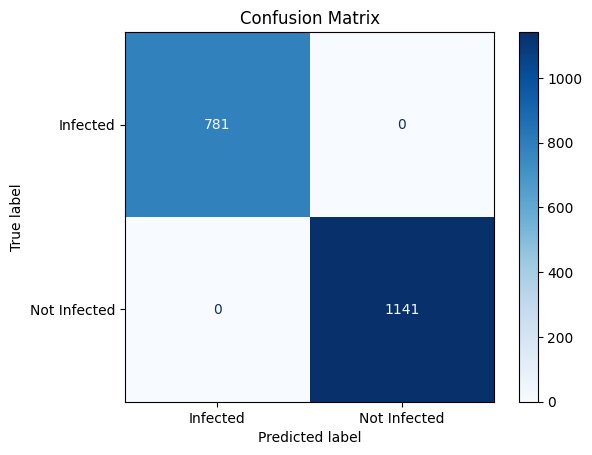

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()
test_loss = 0.0
correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_loss /= len(test_loader)
test_acc = 100. * correct / total
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.2f}%")

# Calculer
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=categories)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


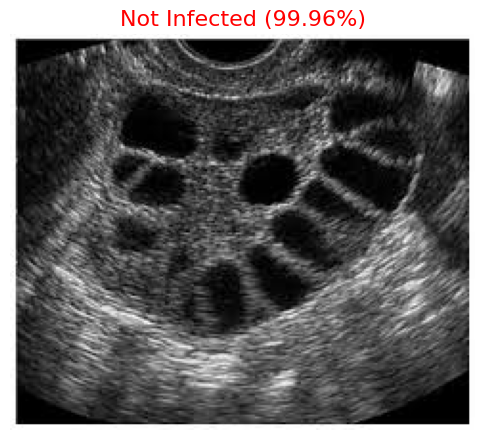

In [28]:
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn.functional as F

def predict_and_display_image(image_path, model, transform, device, categories):

    image = Image.open(image_path).convert('RGB')
    processed_image = transform(image).unsqueeze(0)
    processed_image = processed_image.to(device)

    # faire la  prediction
    model.eval()
    with torch.no_grad():
        outputs = model(processed_image)
        probabilities = F.softmax(outputs, dim=1)
        predicted_idx = probabilities.argmax(1).item()
        predicted_class = categories[predicted_idx]
        predicted_prob = probabilities[0, predicted_idx].item()

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"{predicted_class} ({predicted_prob*100:.2f}%)", fontsize=16, color='red')
    plt.show()

image_path = '/content/pcos_image.pdf'
predict_and_display_image(image_path, model, transform, device, categories)


reference: https://github.com/kalthommusa/Flower-Image-Classifier/blob/master/Project_Image_Classifier_Project.ipynb